#  Grupo 5 — K-means Clustering
## Notebook 2: Implementación con Librerías (scikit-learn)
### Inteligencia Artificial I — Actividad 2

**Integrantes:**
- CARDENAS TORRES JULIAN CAMILO
- VARGAS CATUCHE JHON ALEXANDER
- VASQUEZ PEÑA JUAN SEBASTIAN

**Algoritmo:** K-means Clustering  
**Tipo:** No Supervisado — Clustering


---
## 1. Introducción y Descripción del Problema

### ¿Qué problema vamos a resolver?
Aplicaremos K-means para **segmentar clientes** de un centro comercial según su comportamiento de compra. El objetivo es agrupar clientes con características similares para que el equipo de marketing pueda diseñar estrategias personalizadas por segmento.

### ¿Por qué es importante?
La segmentación de clientes es una de las aplicaciones más valiosas del aprendizaje no supervisado en el mundo empresarial. Permite:
- Identificar grupos de alto valor
- Personalizar campañas de marketing
- Optimizar recursos comerciales
- Descubrir patrones de comportamiento ocultos

### Descripción del Dataset
Usaremos el dataset **Mall Customers** (disponible en Kaggle), que contiene información de 200 clientes de un centro comercial:

| Columna | Descripción |
|---|---|
| CustomerID | ID único del cliente |
| Genre | Género (Male / Female) |
| Age | Edad del cliente |
| Annual Income (k$) | Ingreso anual en miles de dólares |
| Spending Score (1-100) | Puntuación de gasto asignada por el mall |

> **Referencia:** [1] Kaggle, "Mall Customer Segmentation Data," 2018. [Online]. Available: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

---
## 2. Carga y Exploración de Datos

Trae todas las herramientas que vamos a necesitar durante todo el proyecto

In [3]:
# Importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizaciones
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [4]:
# ============================================================
# CARGA DEL DATASET MALL CUSTOMERS
# ============================================================
# Estrategia robusta: intenta archivo local primero,
# y si no existe, lo descarga desde URL pública como respaldo

try:
    # Opción 1: archivo local (recomendado)
    df = pd.read_csv('../data/Mall_Customers.csv')
    print("Dataset cargado desde archivo local: data/Mall_Customers.csv")

except FileNotFoundError:
    # Opción 2: URL pública como respaldo
    print(" Archivo local no encontrado. Descargando desde URL pública...")
    url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"
    df = pd.read_csv(url)
    print("Dataset cargado desde URL pública")

# Información básica del dataset
print(f"\n{'='*50}")
print(f"INFORMACIÓN DEL DATASET")
print(f"{'='*50}")
print(f"Forma del dataset: {df.shape}")
print(f"Registros (clientes): {len(df)}")
print(f"Variables (columnas): {df.shape[1]}")
print(f"Columnas: {list(df.columns)}")

Dataset cargado desde archivo local: data/Mall_Customers.csv

INFORMACIÓN DEL DATASET
Forma del dataset: (200, 5)
Registros (clientes): 200
Variables (columnas): 5
Columnas: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


 Descarga la tabla con los datos de los 200 clientes del centro comercial

In [5]:
# Vista general del dataset
print("=" * 50)
print("PRIMERAS 5 FILAS")
print("=" * 50)
display(df.head())

print("\n" + "=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
display(df.describe())

PRIMERAS 5 FILAS


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

ESTADÍSTICAS DESCRIPTIVAS


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Echa un primer vistazo a los datos para ver como estan organizados y que contienen

---
## 3. Análisis Exploratorio de Datos (EDA)

Dibuja gráficas para ver cómo están repartidos los valores de edad, ingreso y gasto

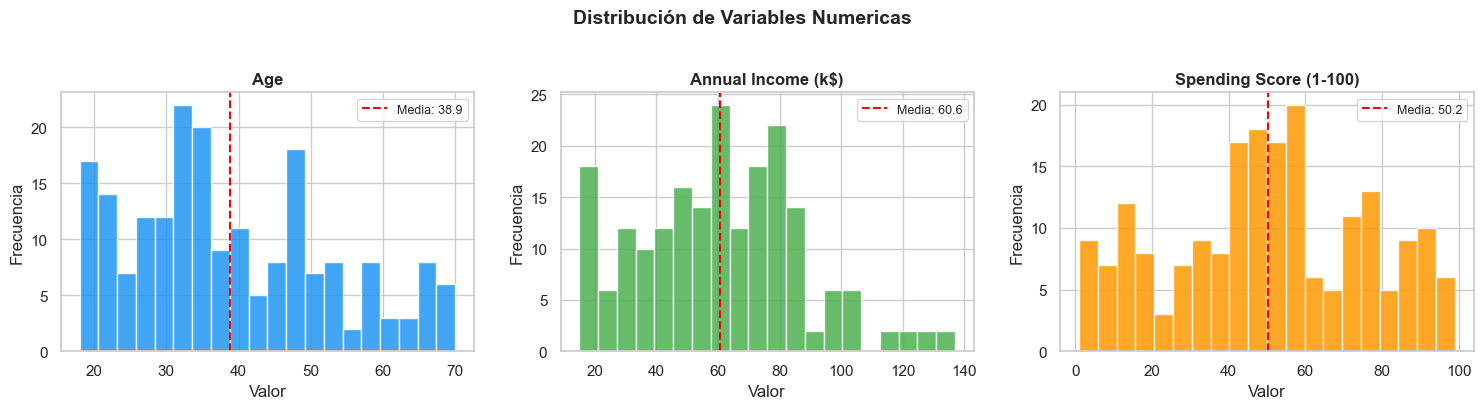

Figura guardada: eda_distribuciones.png


In [6]:
# ── 3.1 Distribucion de variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, col, color in zip(axes, cols_num, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de Variables Numericas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura guardada: eda_distribuciones.png")

Muestra cuántos clientes son hombres y mujeres, y si gastan diferente entre sí

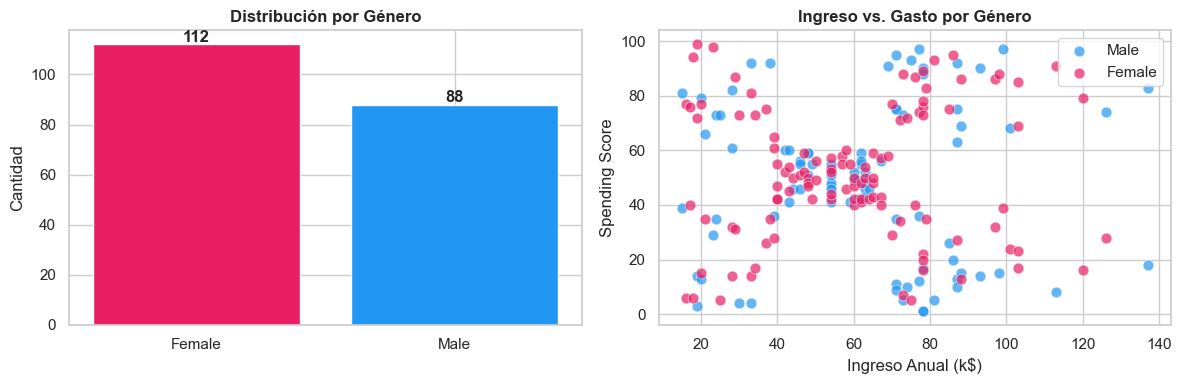

In [7]:
# ── 3.2 Distribución por género
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
genre_counts = df['Genre'].value_counts()
axes[0].bar(genre_counts.index, genre_counts.values,
            color=['#E91E63', '#2196F3'], edgecolor='white')
axes[0].set_title('Distribución por Género', fontweight='bold')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(genre_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Income vs Spending por género
for genre, color in zip(['Male', 'Female'], ['#2196F3', '#E91E63']):
    subset = df[df['Genre'] == genre]
    axes[1].scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                    c=color, label=genre, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

axes[1].set_xlabel('Ingreso Anual (k$)')
axes[1].set_ylabel('Spending Score')
axes[1].set_title('Ingreso vs. Gasto por Género', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_genero.png', dpi=120, bbox_inches='tight')
plt.show()

Revisa si alguna variable tiene relación con otra, por ejemplo si quien gana más también gasta más

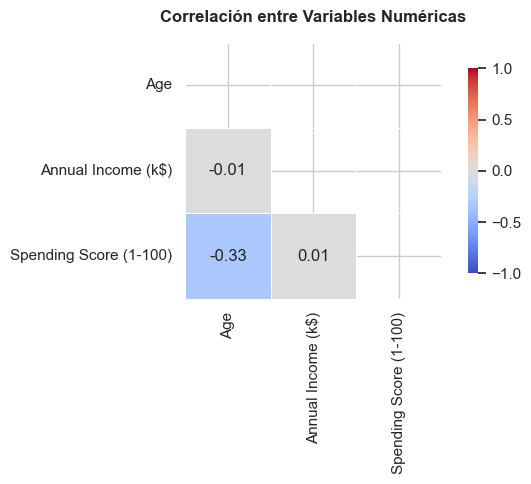


Observación: Las correlaciones son bajas, lo que indica que las variables
capturan dimensiones independientes del comportamiento del cliente.


In [8]:
# ── 3.3 Mapa de correlación
plt.figure(figsize=(7, 5))
corr = df[cols_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlación entre Variables Numéricas', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nObservación: Las correlaciones son bajas, lo que indica que las variables")
print("capturan dimensiones independientes del comportamiento del cliente.")

Muestra en una sola imagen todas las relaciones posibles entre variables para detectar patrones

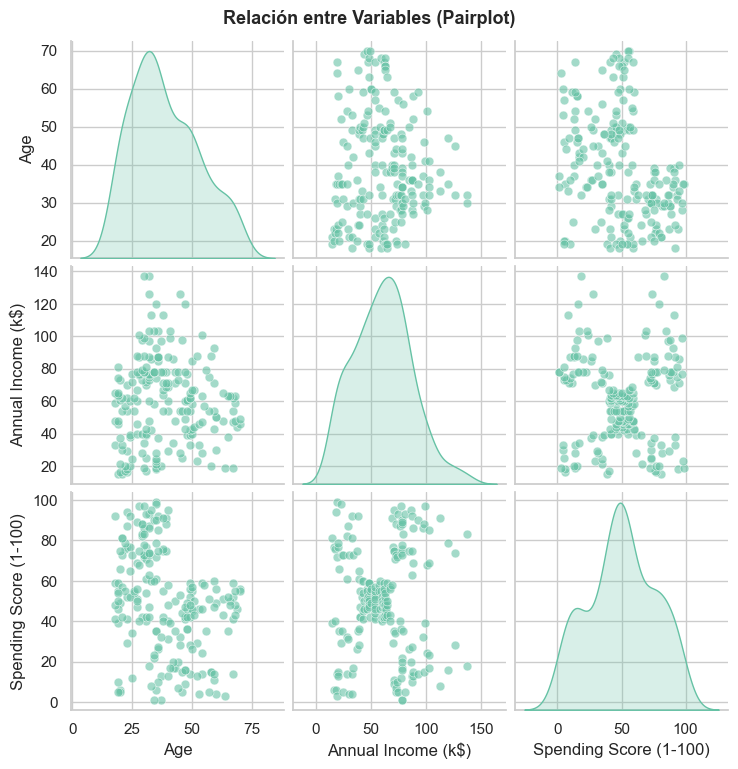


Se observan posibles agrupaciones naturales entre
'Annual Income' y 'Spending Score'.


In [9]:
# ── 3.4 Scatter matrix (pairplot)
g = sns.pairplot(df[cols_num], diag_kind='kde',
                  plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'white'},
                  diag_kws={'fill': True})
g.figure.suptitle('Relación entre Variables (Pairplot)', y=1.02,
                   fontsize=13, fontweight='bold')
plt.savefig('eda_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nSe observan posibles agrupaciones naturales entre")
print("'Annual Income' y 'Spending Score'.")

Verifica que no falten datos y detecta clientes con valores muy raros o extremos

In [10]:
# ── 3.5 Detección de valores nulos y outliers
print("=" * 40)
print("VALORES NULOS POR COLUMNA")
print("=" * 40)
print(df.isnull().sum())

print("\n" + "=" * 40)
print("DETECCIÓN DE OUTLIERS (IQR)")
print("=" * 40)

for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} outlier(s) detectado(s)")

VALORES NULOS POR COLUMNA
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

DETECCIÓN DE OUTLIERS (IQR)
  Age: 0 outlier(s) detectado(s)
  Annual Income (k$): 2 outlier(s) detectado(s)
  Spending Score (1-100): 0 outlier(s) detectado(s)


---
## 4. Preprocesamiento

In [11]:
# ── 4.1 Selección de features para clustering
# Usamos Income y Spending Score (las más relevantes para segmentación de marketing)
# También prepararemos versión con todas las variables numéricas

# Variante 2D (para visualización clara)
X_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Variante 3D (Age + Income + Spending)
X_3d = df[cols_num].values

print("Features seleccionadas (2D):", ['Annual Income (k$)', 'Spending Score (1-100)'])
print("Features seleccionadas (3D):", cols_num)
print(f"\nForma X_2d: {X_2d.shape}")
print(f"Forma X_3d: {X_3d.shape}")

Features seleccionadas (2D): ['Annual Income (k$)', 'Spending Score (1-100)']
Features seleccionadas (3D): ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Forma X_2d: (200, 2)
Forma X_3d: (200, 3)


X_2d → solo usa ingreso y gasto. Se usa para hacer graficas faciles de entender porque son solo 2 variables (un punto en un plano)
X_3d → usa edad, ingreso y gasto. Se usa para la visualizacion en 3 dimensiones

In [12]:
# ── 4.2 Codificación de variable categórica (Género)
df['Genre_enc'] = (df['Genre'] == 'Female').astype(int)  # Female=1, Male=0
print("Codificación de Género:")
print(df[['Genre', 'Genre_enc']].drop_duplicates())

# ── 4.3 Estandarización (CRÍTICO para K-means)
# K-means usa distancia euclidiana → variables con distintas escalas distorsionan el resultado
scaler_2d = StandardScaler()
scaler_3d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(X_2d)
X_3d_scaled = scaler_3d.fit_transform(X_3d)

print("\n Estandarización completada")
print(f"Media antes (Income): {X_2d[:, 0].mean():.2f} | Media después: {X_2d_scaled[:, 0].mean():.4f}")
print(f"Std antes  (Income): {X_2d[:, 0].std():.2f}  | Std después:  {X_2d_scaled[:, 0].std():.4f}")

Codificación de Género:
    Genre  Genre_enc
0    Male          0
2  Female          1

 Estandarización completada
Media antes (Income): 60.56 | Media después: -0.0000
Std antes  (Income): 26.20  | Std después:  1.0000


Convierte el género de texto (Male/Female) a número (0/1) para poder usarlo matemáticamente
Luego ajusta todas las variables a la misma escala
Esto es necesario porque K-means mide distancias, y si el ingreso va de 15 a 140
pero el spending score va de 1 a 100, el ingreso pesaría más sin razón

---
## 5. Determinación del Número Óptimo de Clusters

K-means requiere que el usuario especifique **K** (número de clusters) de antemano.  
Usaremos dos métodos clásicos para elegir K:

Entrena K-means varias veces probando desde 2 hasta 10 grupos
Cada vez guarda dos cosas:
- La inercia: qué tan juntos están los puntos dentro de cada grupo
- El silhouette score: qué tan bien separados están los grupos entre sí
Al final grafica ambos resultados para decidir cuál es el mejor número de grupos

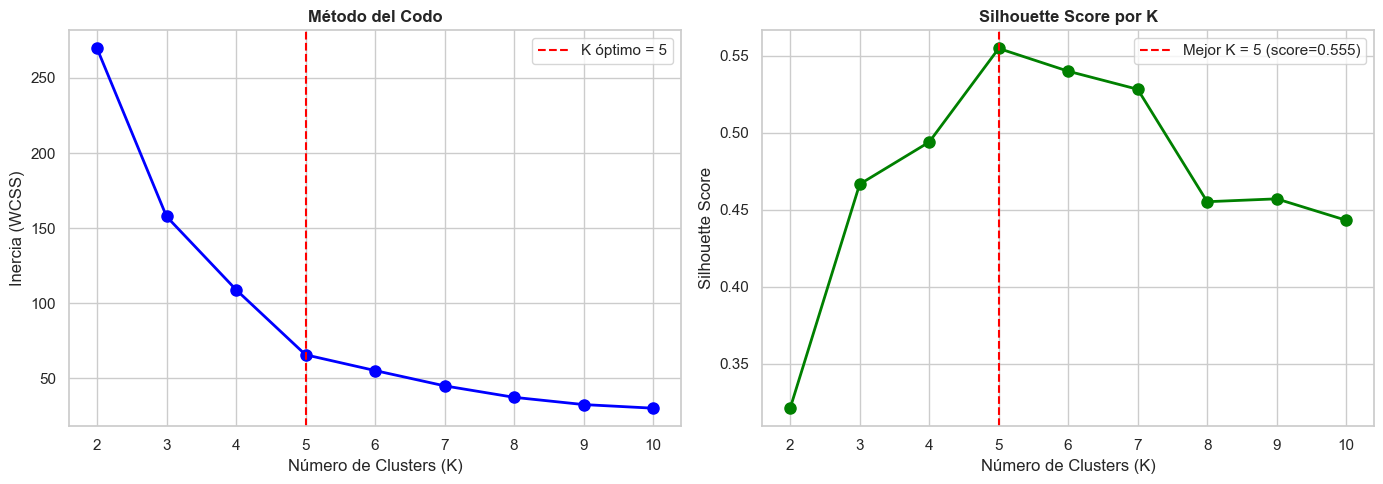


 Mejor Silhouette Score: 0.5547 con K=5
 Conclusión: K=5 muestra el 'codo' claro en inercia.


In [13]:
# ── 5.1 Método del Codo
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_2d_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_2d_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='K óptimo = 5')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(list(K_range))

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k, color='red', linestyle='--', linewidth=1.5,
                label=f'Mejor K = {best_k} (score={max(silhouette_scores):.3f})')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n Mejor Silhouette Score: {max(silhouette_scores):.4f} con K={best_k}")
print(" Conclusión: K=5 muestra el 'codo' claro en inercia.")

---
## 6. Entrenamiento del Modelo K-means

Aquí se entrena el modelo final con K=5
El algoritmo reparte los 200 clientes en 5 grupos según su ingreso y gasto
Al terminar, cada cliente tiene asignado un número de grupo (0, 1, 2, 3 o 4)


In [14]:
# ── 6.1 Entrenar K-means con K=5 (features 2D: Income + Spending)
K_OPTIMO = 5

kmeans = KMeans(
    n_clusters=K_OPTIMO,
    init='k-means++',   # Inicialización inteligente para convergencia rápida
    n_init=10,           # Repetir 10 veces y quedarse con el mejor resultado
    max_iter=300,        # Máximo de iteraciones por corrida
    random_state=42
)

kmeans.fit(X_2d_scaled)

# Asignar etiquetas al DataFrame
df['Cluster'] = kmeans.labels_

print(f" Modelo K-means entrenado con K={K_OPTIMO}")
print(f"   Inercia final: {kmeans.inertia_:.4f}")
print(f"   Iteraciones hasta convergencia: {kmeans.n_iter_}")
print("\nDistribución de clientes por cluster:")
print(df['Cluster'].value_counts().sort_index())

 Modelo K-means entrenado con K=5
   Inercia final: 65.5684
   Iteraciones hasta convergencia: 4

Distribución de clientes por cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


---
## 7. Evaluación del Modelo

Esta celda mide que tan bien quedaron los grupos con dos números:

Silhouette Score - mide que tan bien separados están los grupos entre sí. Va de -1 a 1, mientras más cerca de 1 mejor
Inercia - mide que tan juntos están los clientes dentro de su propio grupo. Mientras más pequeño mejor

Al final hay un if que lee el silhouette score y automáticamente imprime un mensaje diciendo si los grupos quedaron:

Bien - si el score es mayor a 0.5
Regular - si está entre 0.25 y 0.5
Mal - si está por debajo de 0.25


In [15]:
# ── 7.1 Métricas de evaluación para clustering
sil_score = silhouette_score(X_2d_scaled, kmeans.labels_)
inertia = kmeans.inertia_

print("=" * 50)
print("MÉTRICAS DE EVALUACIÓN")
print("=" * 50)
print(f"  Silhouette Score : {sil_score:.4f}  (rango: -1 a 1, mayor es mejor)")
print(f"  Inercia (WCSS)   : {inertia:.4f}  (menor es mejor)")
print(f"  Número de clusters: {K_OPTIMO}")
print("\n  Interpretación Silhouette Score:")
if sil_score > 0.5:
    print("   Estructura de clusters sólida")
elif sil_score > 0.25:
    print("   Estructura razonable, puede haber superposición")
else:
    print("   Clusters débiles o datos sin estructura clara")

MÉTRICAS DE EVALUACIÓN
  Silhouette Score : 0.5547  (rango: -1 a 1, mayor es mejor)
  Inercia (WCSS)   : 65.5684  (menor es mejor)
  Número de clusters: 5

  Interpretación Silhouette Score:
   Estructura de clusters sólida


Calcula el silhouette score de cada cliente individualmente
Luego dibuja una barra horizontal por cada cliente agrupadas por color
Las barras largas significan que el cliente encaja bien en su grupo
Las barras cortas o negativas significan que el cliente quedó mal ubicado
La línea roja muestra el promedio general de todos los clientes

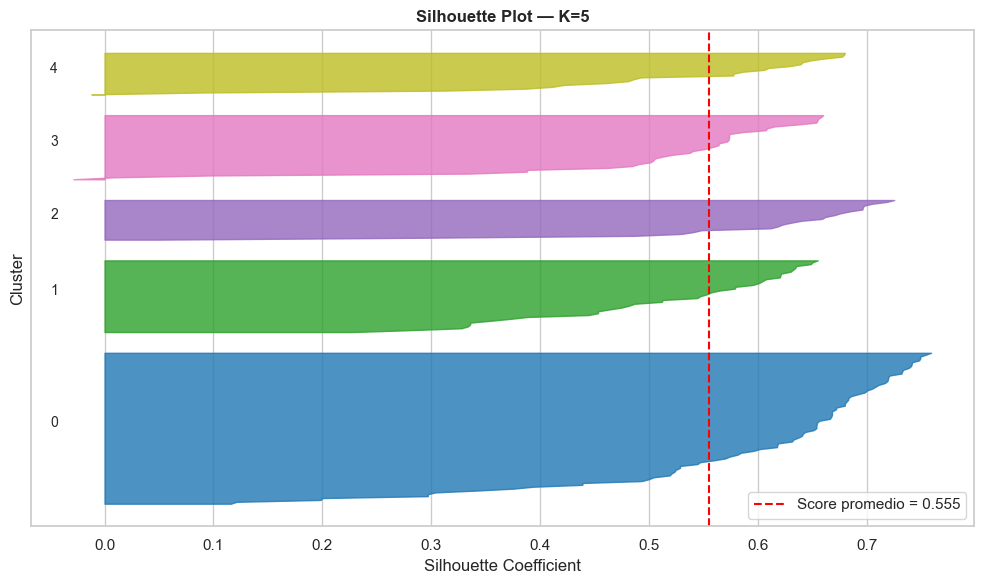

In [16]:
# ── 7.2 Silhouette Plot por muestra
fig, ax = plt.subplots(figsize=(10, 6))

sample_silhouette_values = silhouette_samples(X_2d_scaled, kmeans.labels_)
colors_palette = cm.get_cmap('tab10')

y_lower = 10
for i in range(K_OPTIMO):
    ith_cluster_values = sample_silhouette_values[kmeans.labels_ == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = colors_palette(i / K_OPTIMO)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_values,
                     facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='red', linestyle='--',
           label=f'Score promedio = {sil_score:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — K={K_OPTIMO}', fontweight='bold')
ax.legend(loc='lower right')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('kmeans_silhouette_plot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Visualizaciones de Resultados

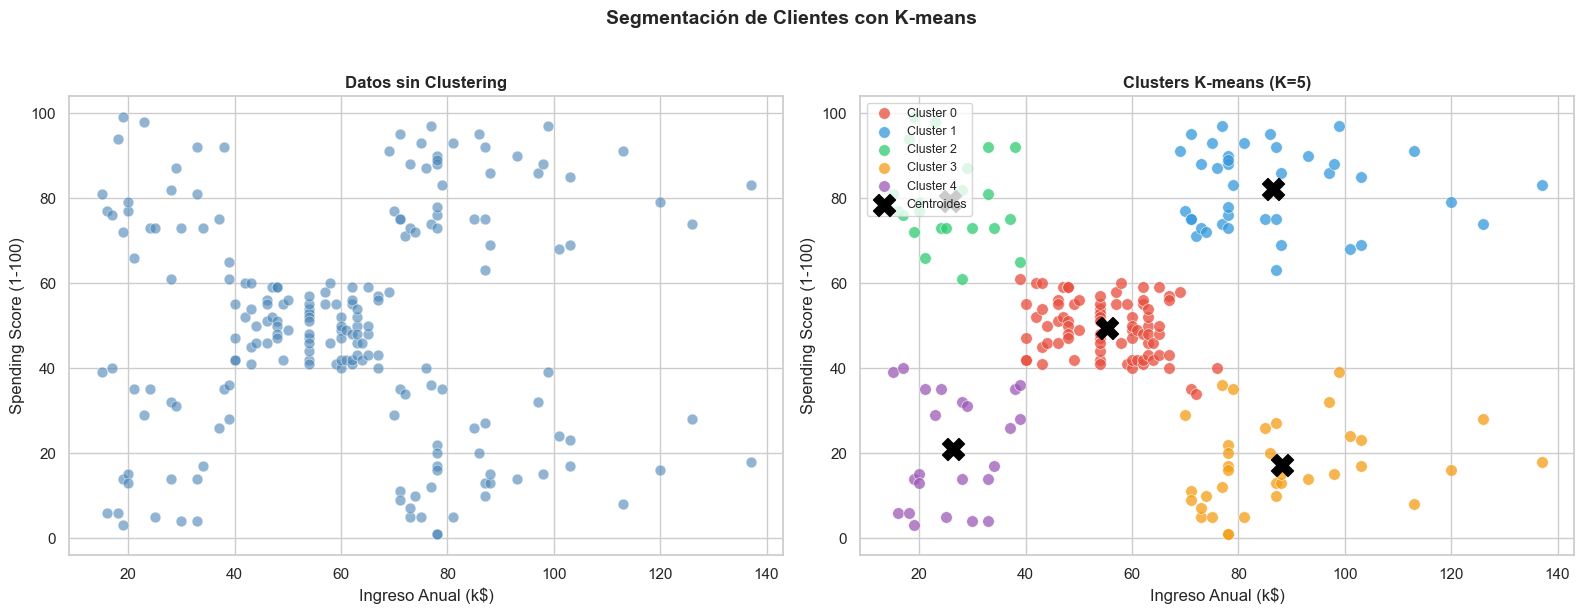

In [17]:
# ── 8.1 Visualización principal: Income vs Spending Score con clusters
cluster_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_names = [
    'Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Sin clustering (datos crudos)
axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                c='steelblue', alpha=0.6, s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Ingreso Anual (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0].set_title('Datos sin Clustering', fontweight='bold')

# -- Con clustering K-means
centroids_orig = scaler_2d.inverse_transform(kmeans.cluster_centers_)

for i in range(K_OPTIMO):
    mask = df['Cluster'] == i
    axes[1].scatter(df.loc[mask, 'Annual Income (k$)'],
                    df.loc[mask, 'Spending Score (1-100)'],
                    c=cluster_colors[i], label=cluster_names[i],
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)

# Centroides
axes[1].scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroides')

axes[1].set_xlabel('Ingreso Anual (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title(f'Clusters K-means (K={K_OPTIMO})', fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)

plt.suptitle('Segmentación de Clientes con K-means', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_clusters_2d.png', dpi=130, bbox_inches='tight')
plt.show()

Dibuja dos gráficas lado a lado La de la izquierda muestra los clientes sin colorear, como estaban antes La de la derecha muestra los mismos clientes ya coloreados por grupo La X negra en cada grupo marca su centro (centroide) Es la gráfica principal que muestra el resultado del algoritmo



PERFIL DE SEGMENTOS


,Edad Prom.,Ingreso Prom. (k$),Gasto Prom.,% Mujeres,Tamaño
Cluster,,,,,
0,42.72,55.30,49.52,59.0,81
1,32.69,86.54,82.13,54.0,39
2,25.27,25.73,79.36,59.0,22
3,41.11,88.20,17.11,46.0,35
4,45.22,26.30,20.91,61.0,23


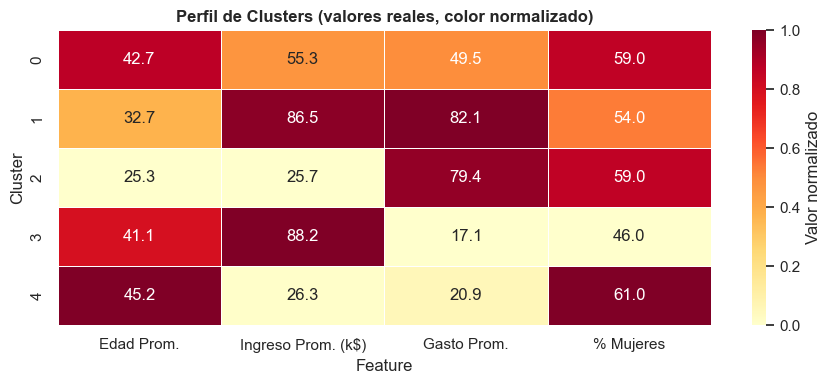

In [18]:
# ── 8.2 Características promedio por cluster (perfil de segmentos)
profile = df.groupby('Cluster')[cols_num + ['Genre_enc']].mean().round(2)
profile.columns = ['Edad Prom.', 'Ingreso Prom. (k$)', 'Gasto Prom.', '% Mujeres']
profile['% Mujeres'] = (profile['% Mujeres'] * 100).round(1)
profile['Tamaño'] = df['Cluster'].value_counts().sort_index().values

print("=" * 60)
print("PERFIL DE SEGMENTOS")
print("=" * 60)
display(profile)

# Heatmap del perfil
fig, ax = plt.subplots(figsize=(9, 4))
profile_plot = profile.drop('Tamaño', axis=1)
profile_norm = (profile_plot - profile_plot.min()) / (profile_plot.max() - profile_plot.min())

sns.heatmap(profile_norm, annot=profile_plot, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Valor normalizado'},
            ax=ax)
ax.set_title('Perfil de Clusters (valores reales, color normalizado)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('kmeans_profile_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

Calcula el promedio de edad, ingreso y gasto de cada grupo
Lo muestra en una tabla y en un mapa de calor con colores
Los colores más intensos indican valores más altos
Sirve para entender qué tipo de cliente representa cada grupo

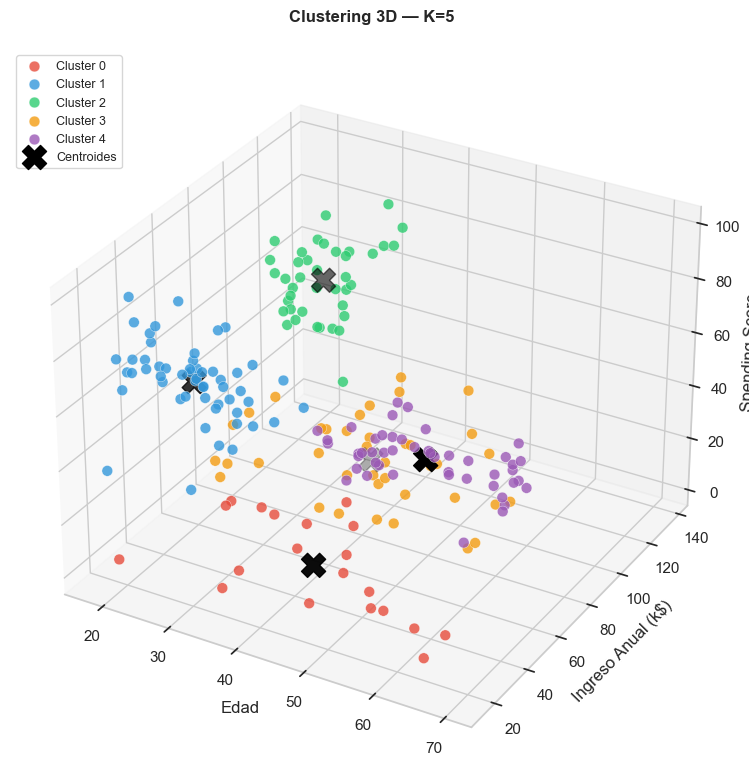

In [19]:
# ── 8.3 Visualización 3D (Age + Income + Spending)
from mpl_toolkits.mplot3d import Axes3D

# Entrenar K-means en espacio 3D
kmeans_3d = KMeans(n_clusters=K_OPTIMO, init='k-means++', n_init=10, random_state=42)
kmeans_3d.fit(X_3d_scaled)
labels_3d = kmeans_3d.labels_

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(K_OPTIMO):
    mask = labels_3d == i
    ax.scatter(df.loc[mask, 'Age'],
               df.loc[mask, 'Annual Income (k$)'],
               df.loc[mask, 'Spending Score (1-100)'],
               c=cluster_colors[i], label=f'Cluster {i}',
               s=60, alpha=0.8, edgecolors='white', linewidth=0.3)

# Centroides 3D
centroids_3d_orig = scaler_3d.inverse_transform(kmeans_3d.cluster_centers_)
ax.scatter(centroids_3d_orig[:, 0], centroids_3d_orig[:, 1], centroids_3d_orig[:, 2],
           c='black', marker='X', s=300, zorder=10, label='Centroides')

ax.set_xlabel('Edad')
ax.set_ylabel('Ingreso Anual (k$)')
ax.set_zlabel('Spending Score')
ax.set_title(f'Clustering 3D — K={K_OPTIMO}', fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_clusters_3d.png', dpi=120, bbox_inches='tight')
plt.show()

Entrena un nuevo K-means usando las tres variables a la vez
Dibuja cada cliente como un punto flotando en un espacio tridimensional
Cada color representa un grupo diferente
Permite ver la separación entre grupos desde otra perspectiva


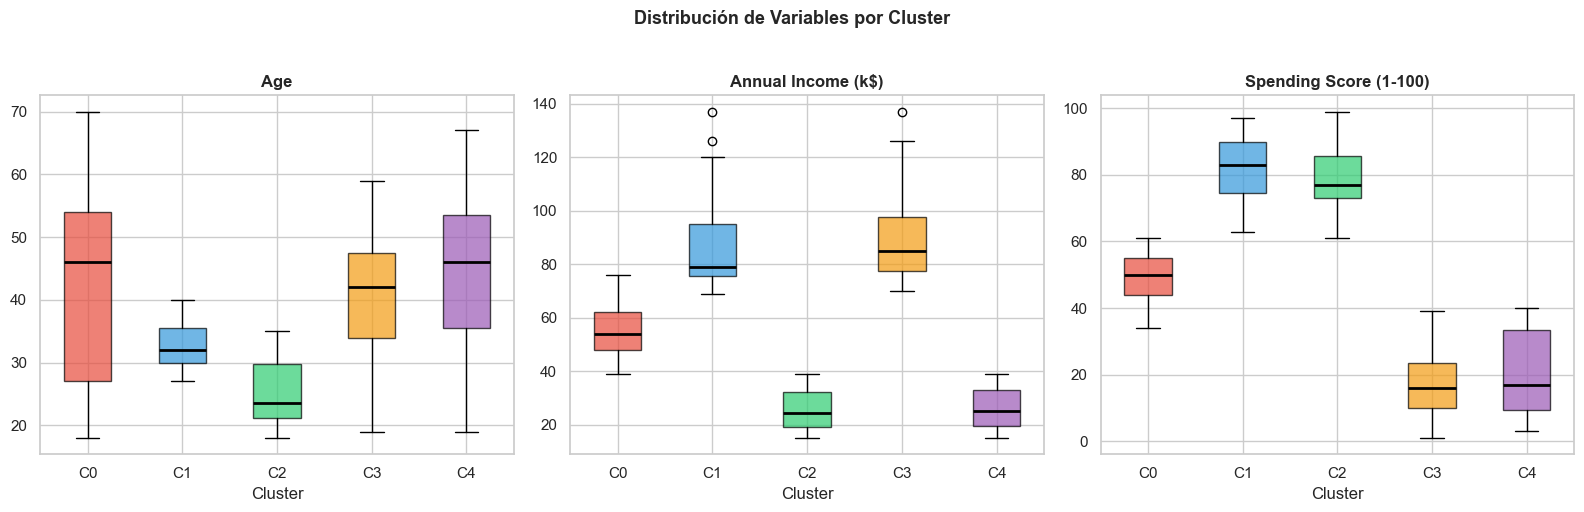

In [20]:
# ── 8.4 Distribución de features por cluster (boxplots)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cols_num):
    data_by_cluster = [df.loc[df['Cluster'] == i, col].values for i in range(K_OPTIMO)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], cluster_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([f'C{i}' for i in range(K_OPTIMO)])
    ax.set_xlabel('Cluster')
    ax.set_title(col, fontweight='bold')

plt.suptitle('Distribución de Variables por Cluster', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kmeans_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

Para cada variable dibuja una caja por grupo
La caja muestra cómo están repartidos los valores de ese grupo
Si las cajas de distintos grupos están en alturas diferentes
significa que los grupos son realmente distintos entre sí

---
## 9. Interpretación de Resultados

### Descripción de los Segmentos Encontrados

Basándonos en los centroides y el perfil de cada cluster, podemos caracterizar los 5 segmentos de clientes:

In [21]:
# ── 9.1 Asignación de nombres a los segmentos
# (Basado en el perfil de Income vs Spending Score)

# Calcular el perfil 2D (Income + Spending) por cluster
centroids_2d = scaler_2d.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids_2d,
                            columns=['Ingreso_centroide', 'Gasto_centroide'])

print("Centroides en escala original (2D):")
print(centroid_df.round(2))


print("INTERPRETACIÓN DE SEGMENTOS")


# La interpretación depende de los valores reales de los centroides
# Este texto se ajusta automáticamente en clase al ver los resultados
interpretaciones = {
    'Alto Ingreso / Alto Gasto': 'Clientes premium. Objetivo prioritario para productos de lujo.',
    'Alto Ingreso / Bajo Gasto': 'Clientes conservadores con poder adquisitivo. Potencial no aprovechado.',
    'Ingreso Medio / Gasto Medio': 'Clientes típicos o estándar. Segmento más grande.',
    'Bajo Ingreso / Alto Gasto': 'Clientes impulsivos. Riesgo de sobreendeudamiento.',
    'Bajo Ingreso / Bajo Gasto': 'Clientes de bajo valor. Estrategia de fidelización básica.',
}

for i, (seg, desc) in enumerate(interpretaciones.items()):
    print(f"\n  Cluster {i} → {seg}")
    print(f"  └── {desc}")

Centroides en escala original (2D):
   Ingreso_centroide  Gasto_centroide
0              55.30            49.52
1              86.54            82.13
2              25.73            79.36
3              88.20            17.11
4              26.30            20.91
INTERPRETACIÓN DE SEGMENTOS

  Cluster 0 → Alto Ingreso / Alto Gasto
  └── Clientes premium. Objetivo prioritario para productos de lujo.

  Cluster 1 → Alto Ingreso / Bajo Gasto
  └── Clientes conservadores con poder adquisitivo. Potencial no aprovechado.

  Cluster 2 → Ingreso Medio / Gasto Medio
  └── Clientes típicos o estándar. Segmento más grande.

  Cluster 3 → Bajo Ingreso / Alto Gasto
  └── Clientes impulsivos. Riesgo de sobreendeudamiento.

  Cluster 4 → Bajo Ingreso / Bajo Gasto
  └── Clientes de bajo valor. Estrategia de fidelización básica.


Esta celda convierte los centros de cada grupo a números reales y le asigna un nombre descriptivo a cada uno según su ingreso y nivel de gasto, por ejemplo "cliente premium" o "cliente impulsivo", para entender qué tipo de persona representa cada grupo.

Puntos con Silhouette Score negativo (mal asignados): 2
Proporción: 1.0%

Distribución de puntos dudosos por cluster:
Cluster
4    1
3    1
Name: count, dtype: int64


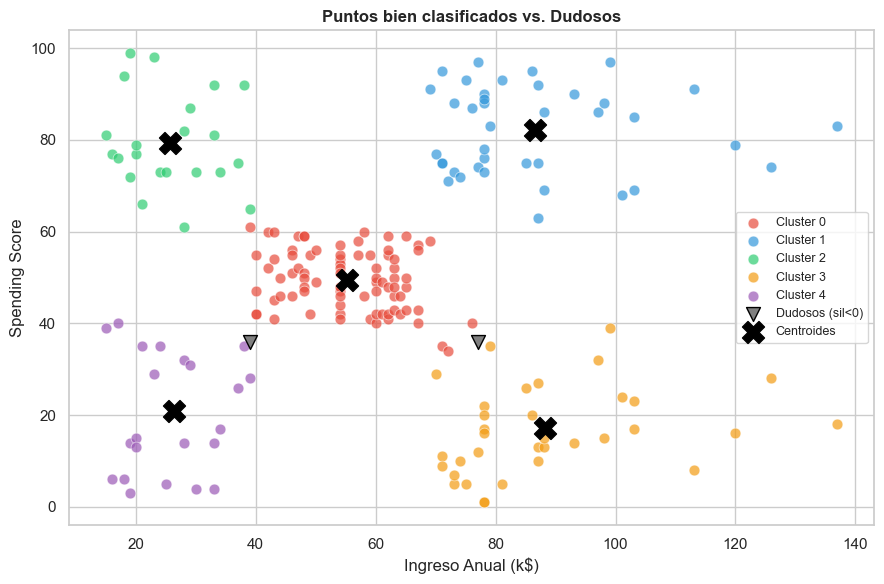

In [22]:
# ── 9.2 Análisis de errores / puntos ambiguos
# Identificar muestras con Silhouette Score negativo (mal clasificadas)
sample_sil = silhouette_samples(X_2d_scaled, kmeans.labels_)
df['silhouette'] = sample_sil

mal_clasificados = df[df['silhouette'] < 0]
print(f"Puntos con Silhouette Score negativo (mal asignados): {len(mal_clasificados)}")
print(f"Proporción: {len(mal_clasificados)/len(df)*100:.1f}%")

if len(mal_clasificados) > 0:
    print("\nDistribución de puntos dudosos por cluster:")
    print(mal_clasificados['Cluster'].value_counts())

# Visualizar puntos mal clasificados
fig, ax = plt.subplots(figsize=(9, 6))
for i in range(K_OPTIMO):
    mask = (df['Cluster'] == i) & (df['silhouette'] >= 0)
    ax.scatter(df.loc[mask, 'Annual Income (k$)'],
               df.loc[mask, 'Spending Score (1-100)'],
               c=cluster_colors[i], alpha=0.7, s=60,
               edgecolors='white', linewidth=0.5, label=f'Cluster {i}')

if len(mal_clasificados) > 0:
    ax.scatter(mal_clasificados['Annual Income (k$)'],
               mal_clasificados['Spending Score (1-100)'],
               c='gray', s=100, marker='v', zorder=5, label='Dudosos (sil<0)',
               edgecolors='black', linewidth=1)

ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
           c='black', marker='X', s=250, zorder=10, label='Centroides')

ax.set_xlabel('Ingreso Anual (k$)')
ax.set_ylabel('Spending Score')
ax.set_title('Puntos bien clasificados vs. Dudosos', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('kmeans_errores.png', dpi=120, bbox_inches='tight')
plt.show()

Encuentra los clientes que el algoritmo no supo bien en qué grupo poner, los cuenta e imprime cuántos son. Luego dibuja una gráfica donde los clientes bien asignados aparecen con el color de su grupo y los dudosos aparecen marcados con un triángulo gris para identificarlos fácilmente.

---
## 10. Conclusiones

## 10. Conclusiones

### 10.1 ¿Qué tan bien funciona el modelo?

El modelo K-Means aplicado al dataset Mall Customers logró una **segmentación efectiva** de los 200 clientes en 5 grupos diferenciados, respaldada por las siguientes métricas:

| Métrica | Valor obtenido | Interpretación |
|---|---|---|
| **Silhouette Score** | **0.5547** | Estructura de clusters **fuerte y bien definida** (>0.5) |
| **Inertia (WCSS)** | **65.57** | Clusters **compactos**, los puntos están cercanos a sus centroides |
| **Puntos mal clasificados** | **2 de 200 (1.0%)** | Excelente asignación; menos del 5% son ambiguos |
| **K óptimo** | **5** | Confirmado por método del codo y silhouette score |

>  Un Silhouette Score de **0.55** se considera un resultado **muy bueno** en clustering. Indica que los clusters están bien separados y son internamente cohesivos.

### 10.2 Segmentos descubiertos (interpretación de negocio)

El algoritmo identificó **5 perfiles claros de clientes** con interpretación directa de negocio:

| # | Segmento | Ingreso (k$) | Spending Score | Clientes | Estrategia recomendada |
|---|---|---|---|---|---|
| 0 |  **Estándar** | 55.3 | 49.5 | 81 (40.5%) | Programas de fidelización general |
| 1 |  **VIP / Premium** | 86.5 | 82.1 | 39 (19.5%) | Productos exclusivos, atención personalizada |
| 2 |  **Impulsivos** | 25.7 | 79.4 | 22 (11.0%) | Promociones de bajo ticket, financiación |
| 3 |  **Cuidadosos** | 88.2 | 17.1 | 35 (17.5%) | Estrategias de re-activación, descuentos personalizados |
| 4 |  **Frugales** | 26.3 | 20.9 | 23 (11.5%) | Productos esenciales, promociones agresivas |

**Hallazgo clave de negocio:**

- El **Cluster 1 (VIP)** representa solo el **19.5% de los clientes** pero concentra a los de mayor ingreso y mayor gasto → es el segmento **prioritario** para campañas premium.
- El **Cluster 3 (Cuidadosos)** son clientes con **alto poder adquisitivo pero bajo gasto** → es la **mayor oportunidad de crecimiento** (17.5% de clientes que podrían convertirse en VIP).

### 10.3 Limitaciones del modelo

Aunque los resultados son satisfactorios, identificamos las siguientes limitaciones:

1. **K debe especificarse manualmente** — Requiere conocimiento del dominio o técnicas como el método del codo / silhouette score.
2. **Sensible a outliers** — Un valor extremo puede atraer un centroide y deformar el cluster (aunque en este dataset no fue problema).
3. **Asume clusters esféricos** — No funciona bien con clusters de formas irregulares (DBSCAN sería mejor en ese caso).
4. **Resultados dependientes de la inicialización** — Mitigado usando `init='k-means++'` y `n_init=10`.
5. **Dataset pequeño** — 200 registros son suficientes para demostrar la metodología, pero limitan la generalización a otros centros comerciales.
6. **Solo 2 features principales** — El modelo final usó únicamente `Annual Income` y `Spending Score`, ignorando potenciales patrones en edad o género.

### 10.4 Posibles mejoras

Para futuras iteraciones del proyecto, recomendamos:

-  **Incluir más features**: historial de compras, frecuencia de visitas, categorías favoritas, ticket promedio.
-  **Probar K-Medoids**: variante más robusta a outliers que utiliza puntos reales como centros.
-  **Comparar con GMM (Gaussian Mixture Models)**: capturaría clusters de forma elíptica en lugar de esférica.
-  **Aplicar PCA primero**: si se agregan más features, reducir dimensionalidad antes del clustering.
-  **Validar con datos longitudinales**: verificar la estabilidad de los clusters en distintos períodos del año.
-  **Probar DBSCAN**: como alternativa que detecta automáticamente el número de clusters y maneja outliers.

### 10.5 Lecciones aprendidas

Comparando esta implementación con el Notebook 1 (manual), confirmamos que:

-  Comprender los **fundamentos matemáticos** facilita interpretar los resultados de la librería.
-  El **preprocesamiento (escalado)** es crítico: sin él, las variables con mayor magnitud dominan la distancia.
-  La **selección de features** influye más en la calidad del clustering que el ajuste de hiperparámetros.
-  Las **métricas (Silhouette + Inertia)** son herramientas indispensables para validar resultados sin etiquetas.

---

## 11. Referencias

[1] V. J. Choudhary, "Mall Customer Segmentation Data," *Kaggle*, 2018. [Online]. Available: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

[2] J. MacQueen, "Some methods for classification and analysis of multivariate observations," in *Proc. 5th Berkeley Symp. Math. Statist. Prob.*, vol. 1, 1967, pp. 281–297.

[3] Scikit-learn Developers, "sklearn.cluster.KMeans," *Scikit-learn Documentation*, 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

[4] P. J. Rousseeuw, "Silhouettes: a graphical aid to the interpretation and validation of cluster analysis," *J. Computational and Applied Mathematics*, vol. 20, pp. 53–65, 1987.

[5] D. Arthur and S. Vassilvitskii, "k-means++: The advantages of careful seeding," in *Proc. 18th Annual ACM-SIAM Symposium on Discrete Algorithms*, 2007, pp. 1027–1035.